# SHAMe m2p3 noise: closest realization to OOD mock

Among the **fixed SHAMe cosmology** ensemble with fixed SHAMe bias and LH over 3 m2p3 noise parameters (`An_homog`, `An2_homog`, `An2_bl`), find the realization whose summary statistics are closest to the **SHAMe OOD mock** ($\bar n = 0.00022$).

**Statistics:** $P(k)$, bispectrum ($k < 0.25\,h$/Mpc, `_kb0.25`), and $P_{gm}(k)$ — same masks as `2026-05-27_shame_noise_params.ipynb`.

**$\chi^2$:** For each probe $s$, use the **diagonal** of the ensemble covariance (variance per bin), then sum across probes:
\[
\chi^2_i = \sum_s w_s \sum_b \frac{(y_{i,s,b}-y_{\mathrm{OOD},s,b})^2}{\mathrm{Var}_s(y_{\cdot,b})}\,,
\]
with tunable probe weights $w_s$ (`CHI2_PROBE_WEIGHTS_M2P3` / `CHI2_PROBE_WEIGHTS_ANMULT`) and **reduced** per-probe terms $\chi^2_s / \nu_s$ ($\nu_s$ = number of masked bins) so probes with different $\nu_s$ are comparable in the joint sum. Per-probe-only bests still minimize unweighted $\chi^2_s$. Block-diagonal across probes, diagonal within each probe. Full $C_s^{-1}$ Mahalanobis is kept only for comparison — it can overweight low-variance correlated modes and pick poor visual matches.

**Alignment:** Bispec files exist for 832/1000 LH indices; we keep only bias-parameter indices present for **all** probes.

See also: `2026-05-27_shame_noise_params.ipynb`, `2026-03-10_load_statistics.ipynb`.


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import data_loader
import utils_model

%load_ext autoreload
%autoreload 2

In [2]:
# --- Tags (fixed SHAMe cosmo + m2p3 noise LH) ---
STATISTICS = ["pk", "bispec", "pgm"]
TAGS_MASK = ["", "_kb0.25", ""]

# Per-probe weights on joint chi2 (per-probe bests stay unweighted)
CHI2_PROBE_WEIGHTS_M2P3 = {
    "pk": 1.0,
    "bispec": 1.0,
    "pgm": 0.1,
}
CHI2_USE_REDUCED_M2P3 = True

CHI2_PROBE_WEIGHTS_ANMULT = {
    "pk": 1.0,
    "bispec": 1.0,
    "pgm": 0.0,
}
CHI2_USE_REDUCED_ANMULT = True

tag_params_shame = "_shame_p0_n1000"
tag_biasparams_shame_noisem2 = "_bias_shame_noisem2_p3_n1000"
tag_noise_shame = "_noise_unit_shame_p0_n1000"

DATA_MODE_TEST_SHAME = "shame"
TAG_MOCK_SHAME = "_nbar0.00022"

NOISE_NAMES = list(utils_model.noiseparam_names_ordered_m2p3)

COLOR_ENSEMBLE = "orange"
COLOR_BEST_JOINT = "crimson"
COLOR_BEST_STAT = "dodgerblue"
COLOR_OOD = "black"
ALPHA_BAND = 0.20
SHAME_LINEWIDTH = 2.2
SHAME_LINESTYLE = "--"


def stats_summary(arr):
    return (
        np.nanmean(arr, axis=0),
        np.nanpercentile(arr, 16, axis=0),
        np.nanpercentile(arr, 84, axis=0),
    )


def plot_fill(ax, x, mean, p16, p84, color, label):
    ax.fill_between(x, p16, p84, color=color, alpha=ALPHA_BAND, label=f"{label} (16–84%)")
    ax.plot(x, mean, color=color, label=f"{label} (mean)")


def chi2_diagonal(Y, y_target, min_var=1e-30):
    """Per-bin chi2: sum_b (y_i,b - y_OOD,b)^2 / Var_ensemble(y_b)."""
    diffs = Y - y_target
    var = np.maximum(np.var(Y, axis=0), min_var)
    return np.sum((diffs ** 2) / var, axis=1)


def chi2_mahalanobis_full(Y, y_target):
    """Full inverse covariance (can be unstable / poor visual match — comparison only)."""
    diffs = Y - y_target
    cov_inv = np.linalg.inv(np.cov(Y, rowvar=False))
    return np.einsum("ni,ij,nj->n", diffs, cov_inv, diffs)


def chi2_block_sum(
    Y_by_stat,
    y_ood_by_stat,
    statistics,
    chi2_fn=chi2_diagonal,
    probe_weights=None,
    use_reduced=True,
):
    """Weighted sum of per-probe chi2 (optionally chi2/n_bins per probe).

    chi2_per_stat always stores the raw per-probe chi2 (for per-probe bests).
    """
    chi2_total = np.zeros(Y_by_stat[statistics[0]].shape[0])
    chi2_per_stat = {}
    for stat in statistics:
        c2 = chi2_fn(Y_by_stat[stat], y_ood_by_stat[stat])
        chi2_per_stat[stat] = c2
        c2_joint = c2 / Y_by_stat[stat].shape[1] if use_reduced else c2
        w = 1.0 if probe_weights is None else float(probe_weights.get(stat, 1.0))
        chi2_total += w * c2_joint
    return chi2_total, chi2_per_stat


def ndof_by_stat(Y_by_stat, statistics):
    return {stat: Y_by_stat[stat].shape[1] for stat in statistics}


def load_ensemble_aligned(statistics, tags_mask, tag_params, tag_bias, tag_noise):
    """Load each probe, mask, align rows on bias-parameter index (idx_bias)."""
    loaded = {}
    for stat, mask in zip(statistics, tags_mask):
        k, y, _, idxs = data_loader.load_data_muchisimocks(
            stat, tag_params, tag_bias, tag_noise=tag_noise
        )
        k, y, _ = data_loader.mask_data(stat, mask, k, y, np.zeros_like(y))
        loaded[stat] = {"k": k, "y": y, "idxs": idxs}

    pk_by_bias = {int(loaded["pk"]["idxs"][i, 1]): i for i in range(len(loaded["pk"]["idxs"]))}
    bi_by_bias = {int(loaded["bispec"]["idxs"][i, 1]): i for i in range(len(loaded["bispec"]["idxs"]))}
    common_bias_idx = sorted(set(pk_by_bias) & set(bi_by_bias))

    Y_by_stat = {
        "pk": loaded["pk"]["y"][[pk_by_bias[b] for b in common_bias_idx]],
        "pgm": loaded["pgm"]["y"][[pk_by_bias[b] for b in common_bias_idx]],
        "bispec": loaded["bispec"]["y"][[bi_by_bias[b] for b in common_bias_idx]],
    }
    k_by_stat = {stat: loaded[stat]["k"] for stat in statistics}
    return common_bias_idx, k_by_stat, Y_by_stat


def format_ax_loglog(ax, title, xlabel, ylabel):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(loc="best", fontsize=7)
    ax.set_title(title)


def format_ax_bispec(ax, title, ylabel):
    ax.set_yscale("log")
    ax.set_xlabel("triangle index (masked bins)")
    ax.set_ylabel(ylabel)
    ax.legend(loc="best", fontsize=7)
    ax.set_title(title)


def noise_legend_label(tag, bias_idx, noise_series, chi2_val=None, noise_names=None):
    """Multi-line legend: tag, bias index, optional chi2, then noise amplitudes."""
    parts = [f"{tag} (bias {bias_idx})"]
    if chi2_val is not None:
        parts[0] += f", $\\chi^2$={chi2_val:.2f}"
    names = NOISE_NAMES if noise_names is None else noise_names
    amp = ", ".join(f"{n}={noise_series[n]:.3g}" for n in names)
    return parts[0] + "\n" + amp


def print_noise_fit_summary(title, bias_idx, noise_series, extra=None, noise_names=None):
    print(title)
    print(f"  bias_idx={bias_idx}")
    names = NOISE_NAMES if noise_names is None else noise_names
    for n in names:
        print(f"  {n:12s} {noise_series[n]: .6f}")
    if extra:
        print(f"  {extra}")
    print()

def run_joint_noise_best(
    tag_biasparams,
    noise_names,
    *,
    ensemble_label="noise LH",
    y_ood_by_stat_in=None,
    probe_weights=None,
    use_reduced=True,
):
    """Load aligned ensemble, chi2 vs OOD mock, return bests and arrays."""
    bias_idx_common, k_by_stat, Y_by_stat = load_ensemble_aligned(
        STATISTICS,
        TAGS_MASK,
        tag_params_shame,
        tag_biasparams,
        tag_noise_shame,
    )
    n_ens = len(bias_idx_common)
    print(f"Aligned ensemble ({ensemble_label}): {n_ens} realizations")
    for stat in STATISTICS:
        print(f"  {stat}: y {Y_by_stat[stat].shape}, k {k_by_stat[stat].shape}")

    biasparams_df, _ = data_loader.load_bias_params(tag_biasparams)
    y_ood = y_ood_by_stat_in
    if y_ood is None:
        _cwd = os.getcwd()
        os.chdir(REPO_ROOT / "code")
        try:
            _, y_ood_list, _ = data_loader.load_data_ood(
                DATA_MODE_TEST_SHAME, STATISTICS, TAG_MOCK_SHAME, tags_mask=TAGS_MASK
            )
        finally:
            os.chdir(_cwd)
        y_ood = {stat: y_ood_list[i] for i, stat in enumerate(STATISTICS)}

    chi2_per_stat = {
        s: chi2_diagonal(Y_by_stat[s], y_ood[s]) for s in STATISTICS
    }
    nu_by_stat = ndof_by_stat(Y_by_stat, STATISTICS)

    chi2_block, _ = chi2_block_sum(
        Y_by_stat, y_ood, STATISTICS,
        chi2_fn=chi2_diagonal,
        probe_weights=probe_weights,
        use_reduced=use_reduced,
    )
    chi2_block_w1, _ = chi2_block_sum(
        Y_by_stat, y_ood, STATISTICS,
        chi2_fn=chi2_diagonal, probe_weights=None, use_reduced=use_reduced,
    )
    chi2_block_raw, _ = chi2_block_sum(
        Y_by_stat, y_ood, STATISTICS,
        chi2_fn=chi2_diagonal,
        probe_weights=probe_weights,
        use_reduced=False,
    )
    chi2_block_full, _ = chi2_block_sum(
        Y_by_stat, y_ood, STATISTICS,
        chi2_fn=chi2_mahalanobis_full,
        use_reduced=use_reduced,
    )

    i_best_joint = int(np.argmin(chi2_block))
    i_best_w1 = int(np.argmin(chi2_block_w1))
    i_best_raw = int(np.argmin(chi2_block_raw))
    i_best_full = int(np.argmin(chi2_block_full))
    bias_best_joint = bias_idx_common[i_best_joint]
    noise_best_joint = biasparams_df.loc[bias_best_joint, noise_names]

    i_best_per_stat = {s: int(np.argmin(chi2_per_stat[s])) for s in STATISTICS}
    bias_best_per_stat = {s: bias_idx_common[i_best_per_stat[s]] for s in STATISTICS}
    noise_best_per_stat = {
        s: biasparams_df.loc[bias_best_per_stat[s], noise_names] for s in STATISTICS
    }

    def reduced_components(i):
        return ", ".join(
            f"{s}={chi2_per_stat[s][i] / nu_by_stat[s]:.3f}" for s in STATISTICS
        )

    return dict(
        probe_weights=probe_weights,
        use_reduced=use_reduced,
        bias_idx_common=bias_idx_common,
        k_by_stat=k_by_stat,
        Y_by_stat=Y_by_stat,
        biasparams_df=biasparams_df,
        y_ood_by_stat=y_ood,
        noise_names=noise_names,
        n_ens=n_ens,
        chi2_per_stat=chi2_per_stat,
        NU_BY_STAT=nu_by_stat,
        chi2_block=chi2_block,
        chi2_block_w1=chi2_block_w1,
        chi2_block_raw=chi2_block_raw,
        chi2_block_full=chi2_block_full,
        i_best_joint=i_best_joint,
        i_best_w1=i_best_w1,
        i_best_raw=i_best_raw,
        i_best_full=i_best_full,
        bias_best_joint=bias_best_joint,
        noise_best_joint=noise_best_joint,
        i_best_per_stat=i_best_per_stat,
        bias_best_per_stat=bias_best_per_stat,
        noise_best_per_stat=noise_best_per_stat,
        reduced_components=reduced_components,
    )


def print_joint_noise_best_summary(res):
    """Print chi2 bests from ``run_joint_noise_best`` output."""
    nn = res["noise_names"]
    print("Joint chi2 settings:", {
        "weights": res["probe_weights"],
        "use_reduced": res["use_reduced"],
        "nu": res["NU_BY_STAT"],
    })
    print()
    print_noise_fit_summary(
        "Joint best (diag, weighted, reduced)",
        res["bias_best_joint"],
        res["noise_best_joint"],
        extra=(
            f"aligned_i={res['i_best_joint']}, $\chi^2_\mathrm{{red,tot}}$="
            f"{res['chi2_block'][res['i_best_joint']]:.3f} "
            f"(per-probe $\chi^2/\nu$: {res['reduced_components'](res['i_best_joint'])})"
        ),
        noise_names=nn,
    )
    if res["i_best_w1"] != res["i_best_joint"]:
        print(
            f"Joint best (w=1, reduced): bias_idx={res['bias_idx_common'][res['i_best_w1']]}, "
            f"chi2_red,tot={res['chi2_block_w1'][res['i_best_w1']]:.3f}"
        )
    if res["i_best_raw"] != res["i_best_joint"]:
        print(
            f"Joint best (weighted, raw sum): bias_idx={res['bias_idx_common'][res['i_best_raw']]}, "
            f"chi2_tot={res['chi2_block_raw'][res['i_best_raw']]:.3f}"
        )
    print()
    for stat in STATISTICS:
        i = res["i_best_per_stat"][stat]
        print_noise_fit_summary(
            f"{stat}-only best (diag)",
            res["bias_best_per_stat"][stat],
            res["noise_best_per_stat"][stat],
            extra=(
                f"aligned_i={i}, $\chi^2_{{{stat}}}$={res['chi2_per_stat'][stat][i]:.3f}"
            ),
            noise_names=nn,
        )
    print(
        "Full-cov joint best (comparison only):",
        f"bias_idx={res['bias_idx_common'][res['i_best_full']]}, "
        f"chi2={res['chi2_block_full'][res['i_best_full']]:.3f}",
    )
    print()

    chi2_df = pd.DataFrame({
        "aligned_i": np.arange(res["n_ens"]),
        "bias_idx": res["bias_idx_common"],
        "chi2_joint_red_weighted": res["chi2_block"],
        "chi2_joint_red_w1": res["chi2_block_w1"],
        "chi2_joint_raw_weighted": res["chi2_block_raw"],
        "chi2_full_red": res["chi2_block_full"],
        **{n: res["biasparams_df"].loc[res["bias_idx_common"], n].values for n in nn},
        **{f"chi2_{s}": res["chi2_per_stat"][s] for s in STATISTICS},
        **{f"chi2red_{s}": res["chi2_per_stat"][s] / res["NU_BY_STAT"][s] for s in STATISTICS},
    }).set_index("aligned_i")
    return chi2_df.sort_values("chi2_joint_red_weighted").head(10)




In [3]:
# --- Load aligned ensemble + SHAMe OOD mock ---

bias_idx_common, k_by_stat, Y_by_stat = load_ensemble_aligned(
    STATISTICS,
    TAGS_MASK,
    tag_params_shame,
    tag_biasparams_shame_noisem2,
    tag_noise_shame,
)
n_ens = len(bias_idx_common)
print(f"Aligned ensemble: {n_ens} realizations (bispec-complete subset of 1000)")
for stat in STATISTICS:
    print(f"  {stat}: y {Y_by_stat[stat].shape}, k {k_by_stat[stat].shape}")

biasparams_df, _ = data_loader.load_bias_params(tag_biasparams_shame_noisem2)

_cwd = os.getcwd()
os.chdir(REPO_ROOT / "code")
try:
    k_ood_list, y_ood_list, _ = data_loader.load_data_ood(
        DATA_MODE_TEST_SHAME, STATISTICS, TAG_MOCK_SHAME, tags_mask=TAGS_MASK
    )
finally:
    os.chdir(_cwd)

y_ood_by_stat = {stat: y_ood_list[i] for i, stat in enumerate(STATISTICS)}

dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_shame_p0_n1000_bias_shame_noisem2_p3_n1000_noise_unit_shame_p0_n1000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_shame_p0_n1000_bias_shame_noisem2_p3_n1000_noise_unit_shame_p0_n1000
Found 1000 diff cosmo pks in /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_shame_p0_n1000_bias_shame_noisem2_p3_n1000_noise_unit_shame_p0_n1000
Masked 0 out of 32 bins
dir_statistics: /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_shame_p0_n1000_bias_shame_noisem2_p3_n1000_noise_unit_shame_p0_n1000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_shame_p0_n1000_bias_shame_noisem2_p3_n1000_noise_unit_shame_p0_n1000
Found 1000 diff cosmo bispecs in /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_shame_p0_n1000_bias_shame_noisem2_p3_n1000_noise_unit_shame_p0_n1000
Masked 153 out of 203 bins
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pgms_mlib

In [4]:
# --- Chi2 with diagonal (per-bin) ensemble variance ---

chi2_per_stat = {
    s: chi2_diagonal(Y_by_stat[s], y_ood_by_stat[s]) for s in STATISTICS
}
NU_BY_STAT = ndof_by_stat(Y_by_stat, STATISTICS)

chi2_block, _ = chi2_block_sum(
    Y_by_stat,
    y_ood_by_stat,
    STATISTICS,
    chi2_fn=chi2_diagonal,
    probe_weights=CHI2_PROBE_WEIGHTS_M2P3,
    use_reduced=CHI2_USE_REDUCED_M2P3,
)

# Same weights but w=1 (probe weights only)
chi2_block_w1, _ = chi2_block_sum(
    Y_by_stat,
    y_ood_by_stat,
    STATISTICS,
    chi2_fn=chi2_diagonal,
    probe_weights=None,
    use_reduced=CHI2_USE_REDUCED_M2P3,
)
i_best_w1 = int(np.argmin(chi2_block_w1))

# Raw (non-reduced) weighted joint for comparison
chi2_block_raw, _ = chi2_block_sum(
    Y_by_stat,
    y_ood_by_stat,
    STATISTICS,
    chi2_fn=chi2_diagonal,
    probe_weights=CHI2_PROBE_WEIGHTS_M2P3,
    use_reduced=False,
)
i_best_raw = int(np.argmin(chi2_block_raw))

# Comparison: full Mahalanobis per probe (old metric)
chi2_block_full, _ = chi2_block_sum(
    Y_by_stat,
    y_ood_by_stat,
    STATISTICS,
    chi2_fn=chi2_mahalanobis_full,
    use_reduced=CHI2_USE_REDUCED_M2P3,
)
i_best_full = int(np.argmin(chi2_block_full))

print("Joint chi2 settings:", {"weights": CHI2_PROBE_WEIGHTS_M2P3, "use_reduced": CHI2_USE_REDUCED_M2P3, "nu": NU_BY_STAT})
print()

# Joint best: weighted sum of per-probe diagonal chi2
i_best_joint = int(np.argmin(chi2_block))
bias_best_joint = bias_idx_common[i_best_joint]
noise_best_joint = biasparams_df.loc[bias_best_joint, NOISE_NAMES]

# Per-statistic best
i_best_per_stat = {s: int(np.argmin(chi2_per_stat[s])) for s in STATISTICS}
bias_best_per_stat = {s: bias_idx_common[i_best_per_stat[s]] for s in STATISTICS}
noise_best_per_stat = {
    s: biasparams_df.loc[bias_best_per_stat[s], NOISE_NAMES] for s in STATISTICS
}

def reduced_components(i):
    return ", ".join(
        f"{s}={chi2_per_stat[s][i] / NU_BY_STAT[s]:.3f}" for s in STATISTICS
    )


print_noise_fit_summary(
    "Joint best (diag, weighted, reduced)",
    bias_best_joint,
    noise_best_joint,
    extra=(
        f"aligned_i={i_best_joint}, $\\chi^2_\\mathrm{{red,tot}}$={chi2_block[i_best_joint]:.3f} "
        f"(per-probe $\\chi^2/\\nu$: {reduced_components(i_best_joint)})"
    ),
)
if i_best_w1 != i_best_joint:
    print(
        f"Joint best (w=1, reduced): bias_idx={bias_idx_common[i_best_w1]}, "
        f"chi2_red,tot={chi2_block_w1[i_best_w1]:.3f}"
    )
if i_best_raw != i_best_joint:
    print(
        f"Joint best (weighted, raw sum): bias_idx={bias_idx_common[i_best_raw]}, "
        f"chi2_tot={chi2_block_raw[i_best_raw]:.3f}"
    )
print()
for stat in STATISTICS:
    print_noise_fit_summary(
        f"{stat}-only best (diag)",
        bias_best_per_stat[stat],
        noise_best_per_stat[stat],
        extra=f"aligned_i={i_best_per_stat[stat]}, $\\chi^2_{{{stat}}}$={chi2_per_stat[stat][i_best_per_stat[stat]]:.3f}",
    )

print(
    "Full-cov joint best (comparison only):",
    f"bias_idx={bias_idx_common[i_best_full]}, chi2={chi2_block_full[i_best_full]:.3f}",
)
print()

chi2_df = pd.DataFrame({
    "aligned_i": np.arange(n_ens),
    "bias_idx": bias_idx_common,
    "chi2_joint_red_weighted": chi2_block,
    "chi2_joint_red_w1": chi2_block_w1,
    "chi2_joint_raw_weighted": chi2_block_raw,
    "chi2_full_red": chi2_block_full,
})
chi2_df = chi2_df.join(biasparams_df.loc[bias_idx_common, NOISE_NAMES].reset_index(drop=True))
for stat in STATISTICS:
    chi2_df[f"chi2_{stat}"] = chi2_per_stat[stat]
    chi2_df[f"chi2red_{stat}"] = chi2_per_stat[stat] / NU_BY_STAT[stat]
chi2_df.sort_values("chi2_joint_red_weighted").head(10)


Joint chi2 settings: {'weights': {'pk': 1.0, 'bispec': 1.0, 'pgm': 0.1}, 'use_reduced': True, 'nu': {'pk': 32, 'bispec': 50, 'pgm': 32}}

Joint best (diag, weighted, reduced)
  bias_idx=994
  An_homog      1.131621
  An2_homog     0.166714
  An2_bl        7.317037
  aligned_i=994, $\chi^2_\mathrm{red,tot}$=0.048 (per-probe $\chi^2/\nu$: pk=0.027, bispec=0.010, pgm=0.100)

Joint best (w=1, reduced): bias_idx=533, chi2_red,tot=0.081
Joint best (weighted, raw sum): bias_idx=714, chi2_tot=1.637

pk-only best (diag)
  bias_idx=602
  An_homog     -1.746871
  An2_homog    -0.017528
  An2_bl        3.792757
  aligned_i=602, $\chi^2_{pk}$=0.539

bispec-only best (diag)
  bias_idx=478
  An_homog     -1.110899
  An2_homog    -0.083734
  An2_bl       -0.831619
  aligned_i=478, $\chi^2_{bispec}$=0.053

pgm-only best (diag)
  bias_idx=533
  An_homog     -0.798057
  An2_homog    -0.015054
  An2_bl        8.499968
  aligned_i=533, $\chi^2_{pgm}$=1.028

Full-cov joint best (comparison only): bias_idx=5

,aligned_i,bias_idx,chi2_joint_red_weighted,chi2_joint_red_w1,chi2_joint_raw_weighted,chi2_full_red,An_homog,An2_homog,An2_bl,chi2_pk,chi2red_pk,chi2_bispec,chi2red_bispec,chi2_pgm,chi2red_pgm
994,994,994,0.047669,0.138009,1.710981,1.987427,1.131621,0.166714,7.317037,0.874281,0.027321,0.515491,0.010310,3.212078,0.100377
714,714,714,0.048484,0.106553,1.637471,1.217705,-0.967144,0.013444,8.012321,1.192186,0.037256,0.238818,0.004776,2.064673,0.064521
663,663,663,0.048802,0.111691,1.667215,1.176321,-1.660867,-0.096133,9.170006,1.150449,0.035952,0.293164,0.005863,2.236026,0.069876
533,533,533,0.052381,0.081292,1.887895,1.059088,-0.798057,-0.015054,8.499968,1.197066,0.037408,0.588036,0.011761,1.027939,0.032123
466,466,466,0.055899,0.166303,1.834641,1.565072,1.164570,-0.002729,2.224787,1.314689,0.041084,0.127406,0.002548,3.925464,0.122671
367,367,367,0.062593,0.256161,2.027905,1.622457,0.763802,-0.048257,-3.065269,1.270457,0.039702,0.069207,0.001384,6.882404,0.215075
969,969,969,0.065107,0.151174,2.187115,1.117490,-1.732869,-0.216871,4.760624,1.593048,0.049783,0.288049,0.005761,3.060182,0.095631
602,602,602,0.067149,0.115787,2.956863,1.678634,-1.746871,-0.017528,3.792757,0.539182,0.016849,2.244743,0.044895,1.729380,0.054043
17,17,17,0.073080,0.251521,2.652614,2.051291,-1.126705,0.015910,1.063722,1.145754,0.035805,0.872402,0.017448,6.344576,0.198268
317,317,317,0.073394,0.125819,2.460331,1.378862,1.264440,-0.138416,6.493671,1.963604,0.061363,0.310329,0.006207,1.863979,0.058249


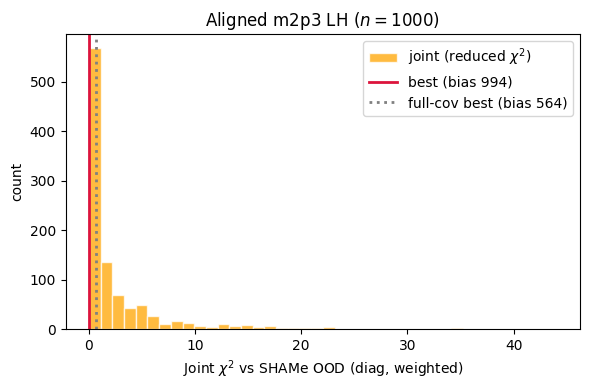

In [5]:
# --- Chi2 distribution ---

fig, ax = plt.subplots(figsize=(6, 4))
red_label = "reduced $\\chi^2$" if CHI2_USE_REDUCED_M2P3 else "$\\chi^2$"
ax.hist(chi2_block, bins=40, color=COLOR_ENSEMBLE, alpha=0.75, edgecolor="white", label=f"joint ({red_label})")
ax.axvline(chi2_block[i_best_joint], color=COLOR_BEST_JOINT, lw=2,
           label=f"best (bias {bias_best_joint})")
if i_best_full != i_best_joint:
    ax.axvline(chi2_block_full[i_best_full], color="gray", ls=":", lw=2,
               label=f"full-cov best (bias {bias_idx_common[i_best_full]})")
ax.set_xlabel(r"Joint $\chi^2$ vs SHAMe OOD (diag, weighted)")
ax.set_ylabel("count")
ax.legend()
ax.set_title(f"Aligned m2p3 LH ($n={n_ens}$)")
plt.tight_layout()
plt.show()


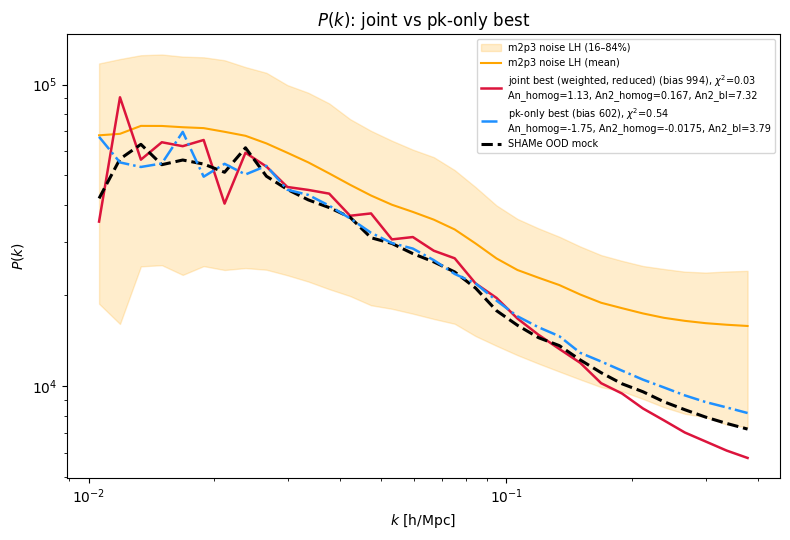

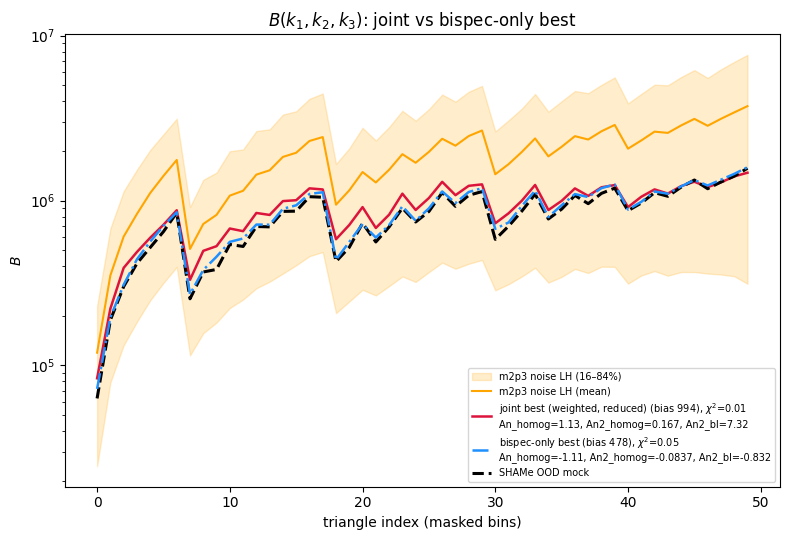

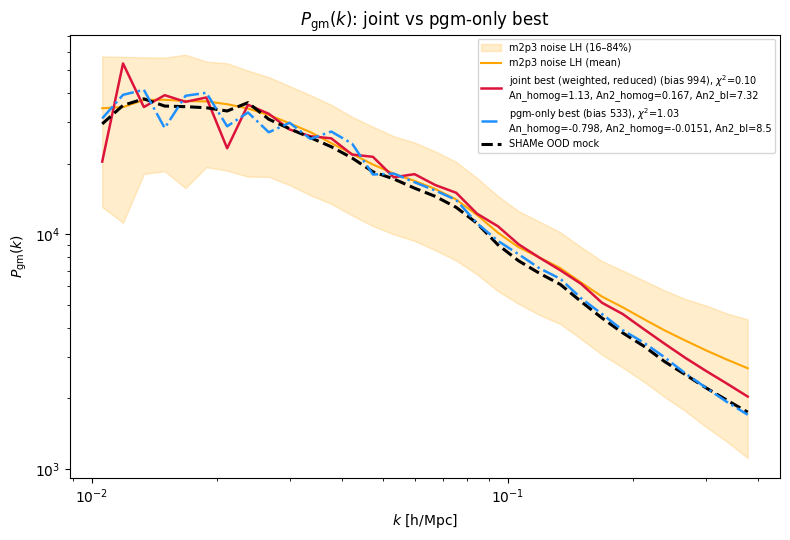

In [6]:
# --- OOD vs joint best and per-probe bests (noise params in legend) ---

STAT_PLOT_META = {
    "pk": dict(title=r"$P(k)$", xlabel=r"$k$ [h/Mpc]", ylabel=r"$P(k)$", loglog=True),
    "bispec": dict(
        title=r"$B(k_1,k_2,k_3)$",
        xlabel="triangle index (masked bins)",
        ylabel=r"$B$",
        loglog=False,
    ),
    "pgm": dict(title=r"$P_\mathrm{gm}(k)$", xlabel=r"$k$ [h/Mpc]", ylabel=r"$P_\mathrm{gm}(k)$", loglog=True),
}

for stat in STATISTICS:
    meta = STAT_PLOT_META[stat]
    y = Y_by_stat[stat]
    x = np.arange(y.shape[1]) if stat == "bispec" else k_by_stat[stat]
    mean, p16, p84 = stats_summary(y)
    i_stat = i_best_per_stat[stat]

    fig, ax = plt.subplots(figsize=(8, 5.5))
    plot_fill(ax, x, mean, p16, p84, COLOR_ENSEMBLE, "m2p3 noise LH")

    ax.plot(
        x,
        y[i_best_joint],
        color=COLOR_BEST_JOINT,
        lw=1.8,
        label=noise_legend_label(
            "joint best (weighted, reduced)",
            bias_best_joint,
            noise_best_joint,
            chi2_per_stat[stat][i_best_joint] / NU_BY_STAT[stat],
        ),
    )
    label_stat = noise_legend_label(
        f"{stat}-only best",
        bias_best_per_stat[stat],
        noise_best_per_stat[stat],
        chi2_per_stat[stat][i_stat],
    )
    if i_stat == i_best_joint:
        label_stat += "\n(same realization as joint best)"
        ax.plot(
            x,
            y[i_stat],
            color=COLOR_BEST_STAT,
            lw=2.4,
            ls=":",
            zorder=4,
            label=label_stat,
        )
    else:
        ax.plot(
            x,
            y[i_stat],
            color=COLOR_BEST_STAT,
            lw=1.8,
            ls="-.",
            zorder=4,
            label=label_stat,
        )

    ax.plot(
        x,
        y_ood_by_stat[stat],
        color=COLOR_OOD,
        linestyle=SHAME_LINESTYLE,
        linewidth=SHAME_LINEWIDTH,
        label="SHAMe OOD mock",
    )

    title = f"{meta['title']}: joint vs {stat}-only best"
    if meta["loglog"]:
        format_ax_loglog(ax, title, meta["xlabel"], meta["ylabel"])
    else:
        format_ax_bispec(ax, title, meta["ylabel"])

    plt.tight_layout()
    plt.show()

## Save joint-best bias + m2p3 noise as a parameter set

Writes `params_fixed` for the registry entry `bias_shame_noisem2best_p0_n1`
(see `PARAM_SETS_LH` in `generate_params.py`). Pair with `_shame_p0_n1000`.

In [7]:
import generate_params as genp

PARAM_SET_NAME = "bias_shame_noisem2best_p0_n1"
cfg = genp.PARAM_SETS_LH[PARAM_SET_NAME]
assert cfg["_authored"]
tag_biasparams = genp.param_set_tag(cfg)

fid = {**utils_model.bias_dict_shame["_nbar0.00022"], **noise_best_joint.to_dict()}
param_names = (
    utils_model.biasparam_names_ordered + utils_model.noiseparam_names_ordered_m2p3
)
fiducial_saved = {pn: float(fid[pn]) for pn in param_names}
fn_fixed = genp.write_authored_params_fixed(
    tag_biasparams,
    fiducial_saved,
    param_names=param_names,
)
print(f"Wrote {fn_fixed}")
print(f"tag_biasparams={tag_biasparams!r}, tag_params='_shame_p0_n1000'")

# Copy-paste reference (commit notebook output or dict below after re-running)
from pprint import pprint

print(f"\n{PARAM_SET_NAME} =")
pprint(
    {
        "tag_biasparams": tag_biasparams,
        "tag_params": "_shame_p0_n1000",
        "bias_idx": int(bias_best_joint),
        "fiducial": fiducial_saved,
    },
    sort_dicts=False,
    width=100,
)

Saved fixed params to /home/kstoreyf/muchisimocks/data/params/params_fixed_bias_shame_noisem2best_p0_n1.txt
Wrote /home/kstoreyf/muchisimocks/data/params/params_fixed_bias_shame_noisem2best_p0_n1.txt
tag_biasparams='_bias_shame_noisem2best_p0_n1', tag_params='_shame_p0_n1000'

bias_shame_noisem2best_p0_n1 =
{'tag_biasparams': '_bias_shame_noisem2best_p0_n1',
 'tag_params': '_shame_p0_n1000',
 'bias_idx': 994,
 'fiducial': {'b1': 0.47410742,
              'b2': 0.12701492,
              'bs2': -0.33881766,
              'bl': -0.82443643,
              'An_homog': 1.1316205294928403,
              'An2_homog': 0.166713641217636,
              'An2_bl': 7.317036671547598}}


## Original Anmult noise (5 parameters)

Same analysis as above, but LH over the **original** multiplicative noise model
(`_bias_shame_noise_p5_n1000`: `An_homog`, `An_b1`, `An_b2`, `An_bs2`, `An_bl`).
Save joint-best to `bias_shame_noisebest_p0_n1`.


In [8]:
tag_biasparams_shame_noise = "_bias_shame_noise_p5_n1000"
NOISE_NAMES_ORIG = list(utils_model.noiseparam_names_ordered)

res_orig = run_joint_noise_best(
    tag_biasparams_shame_noise,
    NOISE_NAMES_ORIG,
    ensemble_label="original Anmult noise LH",
    y_ood_by_stat_in=y_ood_by_stat,
    probe_weights=CHI2_PROBE_WEIGHTS_ANMULT,
    use_reduced=CHI2_USE_REDUCED_ANMULT,
)
chi2_df_orig = print_joint_noise_best_summary(res_orig)
chi2_df_orig



dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_shame_p0_n1000_bias_shame_noise_p5_n1000_noise_unit_shame_p0_n1000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_shame_p0_n1000_bias_shame_noise_p5_n1000_noise_unit_shame_p0_n1000
Found 1000 diff cosmo pks in /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_shame_p0_n1000_bias_shame_noise_p5_n1000_noise_unit_shame_p0_n1000
Masked 0 out of 32 bins
dir_statistics: /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_shame_p0_n1000_bias_shame_noise_p5_n1000_noise_unit_shame_p0_n1000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_shame_p0_n1000_bias_shame_noise_p5_n1000_noise_unit_shame_p0_n1000
Found 941 diff cosmo bispecs in /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_shame_p0_n1000_bias_shame_noise_p5_n1000_noise_unit_shame_p0_n1000
Masked 153 out of 203 bins
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_shame_p

,bias_idx,chi2_joint_red_weighted,chi2_joint_red_w1,chi2_joint_raw_weighted,chi2_full_red,An_homog,An_b1,An_b2,An_bs2,An_bl,chi2_pk,chi2_bispec,chi2_pgm,chi2red_pk,chi2red_bispec,chi2red_pgm
aligned_i,,,,,,,,,,,,,,,,
506,534,0.024803,61.421834,0.811102,21.802616,2.346483,-1.343362,-0.226130,0.526633,1.681377,0.762786,0.048317,1964.704972,0.023837,0.000966,61.397030
840,889,0.041509,71.228412,1.391271,22.823605,1.239013,-2.270100,0.940367,-1.621262,-9.653885,1.216342,0.174930,2277.980890,0.038011,0.003499,71.186903
749,791,0.051498,58.577079,1.676310,21.925436,0.331673,2.095991,-1.216725,2.762763,6.365352,1.597451,0.078860,1872.818594,0.049920,0.001577,58.525581
635,670,0.051825,73.807215,1.685435,25.415997,1.775450,-1.033349,-0.090586,3.268772,-3.603986,1.610319,0.075116,2360.172502,0.050322,0.001502,73.755391
127,127,0.052251,65.761143,1.959367,22.913794,-1.329118,1.799019,0.062569,-0.293835,-3.245566,1.161188,0.798179,2102.684555,0.036287,0.015964,65.708892
743,785,0.053201,61.337374,1.787524,21.713746,-0.168578,1.977445,-0.929951,2.466012,-2.662577,1.551119,0.236404,1961.093540,0.048472,0.004728,61.284173
502,530,0.053746,64.588211,1.758068,22.704028,-1.354193,1.835542,-1.191805,-0.625957,5.217290,1.652007,0.106061,2065.102865,0.051625,0.002121,64.534465
611,646,0.053814,68.521354,1.775829,22.694121,-1.058176,1.712871,-1.466941,1.789870,3.147571,1.626446,0.149383,2190.961264,0.050826,0.002988,68.467539
637,672,0.054251,57.380319,1.998123,20.761645,0.370107,0.466725,-1.443329,1.235322,6.287642,1.270061,0.728062,1834.434176,0.039689,0.014561,57.326068


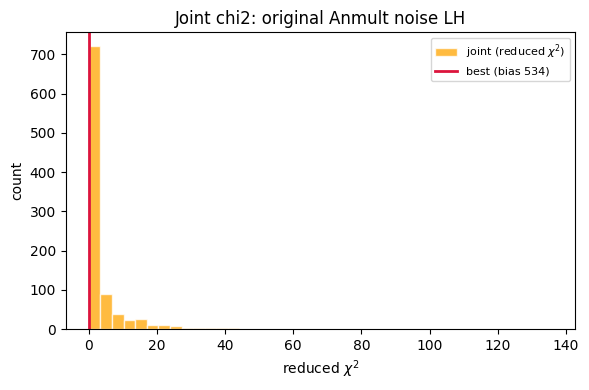

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
red_label = "reduced $\\chi^2$" if res_orig["use_reduced"] else "$\\chi^2$"
ax.hist(
    res_orig["chi2_block"], bins=40, color=COLOR_ENSEMBLE, alpha=0.75,
    edgecolor="white", label=f"joint ({red_label})",
)
ax.axvline(
    res_orig["chi2_block"][res_orig["i_best_joint"]], color=COLOR_BEST_JOINT, lw=2,
    label=f"best (bias {res_orig['bias_best_joint']})",
)
ax.set_xlabel(red_label)
ax.set_ylabel("count")
ax.set_title("Joint chi2: original Anmult noise LH")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()



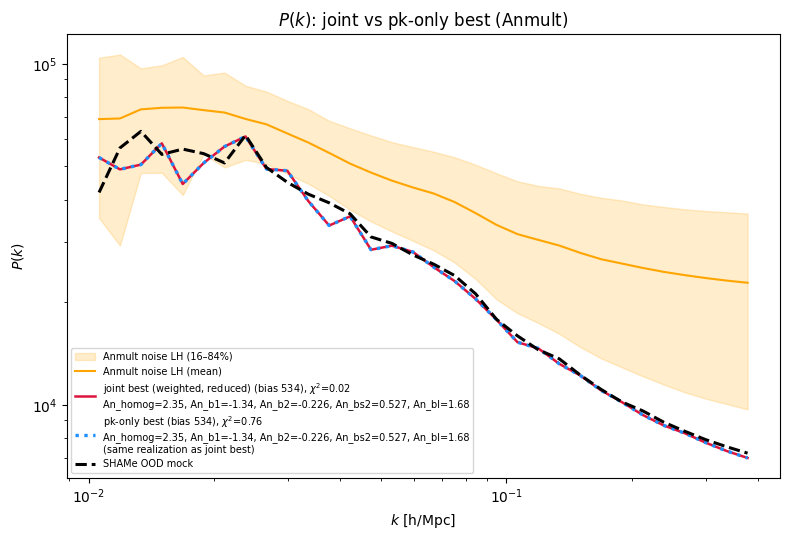

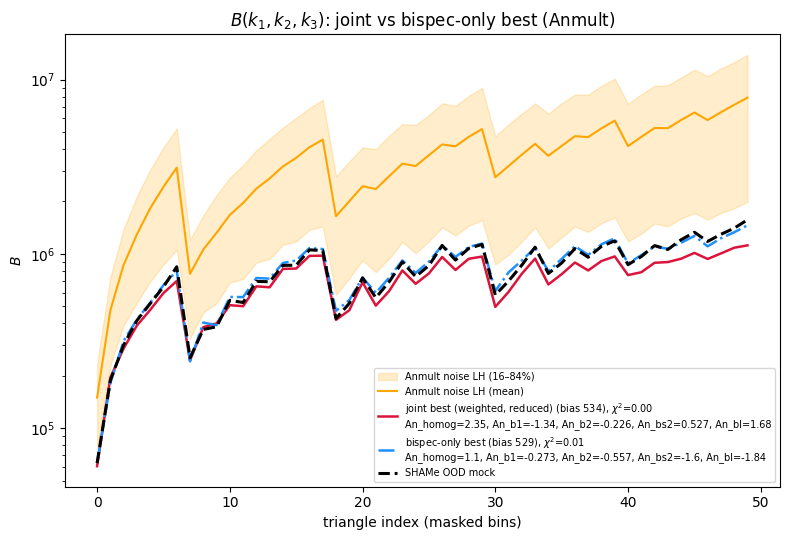

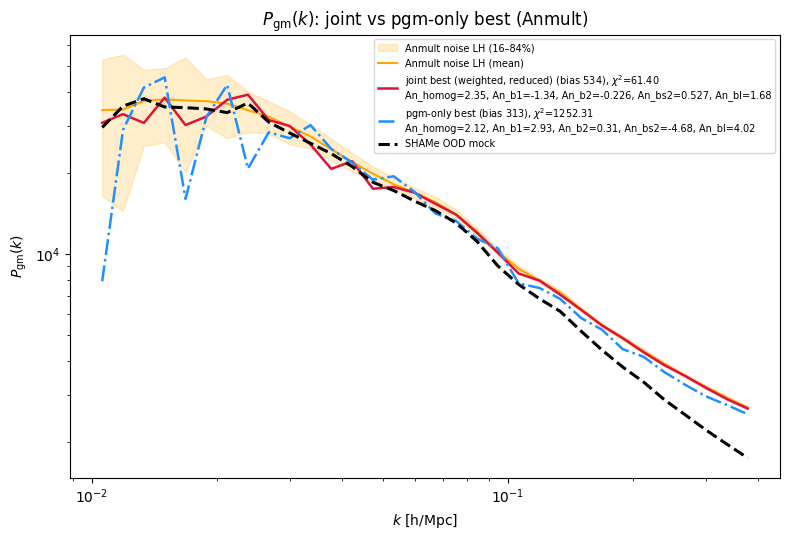

In [10]:
for stat in STATISTICS:
    meta = STAT_PLOT_META[stat]
    y = res_orig["Y_by_stat"][stat]
    x = np.arange(y.shape[1]) if stat == "bispec" else res_orig["k_by_stat"][stat]
    mean, p16, p84 = stats_summary(y)
    i_stat = res_orig["i_best_per_stat"][stat]
    ij = res_orig["i_best_joint"]

    fig, ax = plt.subplots(figsize=(8, 5.5))
    plot_fill(ax, x, mean, p16, p84, COLOR_ENSEMBLE, "Anmult noise LH")
    ax.plot(
        x, y[ij], color=COLOR_BEST_JOINT, lw=1.8,
        label=noise_legend_label(
            "joint best (weighted, reduced)",
            res_orig["bias_best_joint"], res_orig["noise_best_joint"],
            res_orig["chi2_per_stat"][stat][ij] / res_orig["NU_BY_STAT"][stat],
            noise_names=NOISE_NAMES_ORIG,
        ),
    )
    label_stat = noise_legend_label(
        f"{stat}-only best", res_orig["bias_best_per_stat"][stat],
        res_orig["noise_best_per_stat"][stat],
        res_orig["chi2_per_stat"][stat][i_stat], noise_names=NOISE_NAMES_ORIG,
    )
    ls = ":" if i_stat == ij else "-."
    if i_stat == ij:
        label_stat += "\n(same realization as joint best)"
    ax.plot(x, y[i_stat], color=COLOR_BEST_STAT, lw=1.8 if i_stat != ij else 2.4, ls=ls, label=label_stat)
    ax.plot(x, res_orig["y_ood_by_stat"][stat], color=COLOR_OOD,
            linestyle=SHAME_LINESTYLE, linewidth=SHAME_LINEWIDTH, label="SHAMe OOD mock")
    title = f"{meta['title']}: joint vs {stat}-only best (Anmult)"
    if meta["loglog"]:
        format_ax_loglog(ax, title, meta["xlabel"], meta["ylabel"])
    else:
        format_ax_bispec(ax, title, meta["ylabel"])
    plt.tight_layout()
    plt.show()


## Save joint-best (original Anmult noise)

Registry: `bias_shame_noisebest_p0_n1` → `_bias_shame_noisebest_p0_n1`. Pair with `_shame_p0_n1000`.


In [11]:
import generate_params as genp

PARAM_SET_NAME_ORIG = "bias_shame_noisebest_p0_n1"
cfg_orig = genp.PARAM_SETS_LH[PARAM_SET_NAME_ORIG]
assert cfg_orig["_authored"]
tag_biasparams_orig = genp.param_set_tag(cfg_orig)

fid_orig = {
    **utils_model.bias_dict_shame["_nbar0.00022"],
    **res_orig["noise_best_joint"].to_dict(),
}
param_names_orig = (
    utils_model.biasparam_names_ordered + utils_model.noiseparam_names_ordered
)
fiducial_saved_orig = {pn: float(fid_orig[pn]) for pn in param_names_orig}
fn_fixed_orig = genp.write_authored_params_fixed(
    tag_biasparams_orig, fiducial_saved_orig, param_names=param_names_orig,
)
print(f"Wrote {fn_fixed_orig}")
print(f"tag_biasparams={tag_biasparams_orig!r}, tag_params='_shame_p0_n1000'")

from pprint import pprint
print(f"\n{PARAM_SET_NAME_ORIG} =")
pprint(
    {
        "tag_biasparams": tag_biasparams_orig,
        "tag_params": "_shame_p0_n1000",
        "bias_idx": int(res_orig["bias_best_joint"]),
        "fiducial": fiducial_saved_orig,
    },
    sort_dicts=False,
    width=100,
)


Saved fixed params to /home/kstoreyf/muchisimocks/data/params/params_fixed_bias_shame_noisebest_p0_n1.txt
Wrote /home/kstoreyf/muchisimocks/data/params/params_fixed_bias_shame_noisebest_p0_n1.txt
tag_biasparams='_bias_shame_noisebest_p0_n1', tag_params='_shame_p0_n1000'

bias_shame_noisebest_p0_n1 =
{'tag_biasparams': '_bias_shame_noisebest_p0_n1',
 'tag_params': '_shame_p0_n1000',
 'bias_idx': 534,
 'fiducial': {'b1': 0.47410742,
              'b2': 0.12701492,
              'bs2': -0.33881766,
              'bl': -0.82443643,
              'An_homog': 2.346482608623328,
              'An_b1': -1.3433619456637138,
              'An_b2': -0.226130277108882,
              'An_bs2': 0.5266325796844749,
              'An_bl': 1.6813773681515105}}
